In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib.markers import MarkerStyle
from iminuit import Minuit, cost
from scipy.stats import genextreme


my_colors = {
    'VWLS':      '#DC2626',
    'MLE':       '#2563EB',
    'PWM':       '#16A34A',
    'L-moments': '#D97706',
}

my_cmap = plt.colormaps["turbo"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='6,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')


save_figures = True
save_files = False

In [71]:
# Load Data
filename="gev-mu=70,alpha=10,gamma=0.3,N=100000.csv"
directory = "data"
directory_figures="../Figures"
directory_results=directory+"/Results"
filepath = directory+ "/" + filename
print(f"Filepath: {filepath}")
df   = pd.read_csv(filepath)

data = np.array(df.values[:,0])
data;

Filepath: data/gev-mu=70,alpha=10,gamma=0.3,N=100000.csv


In [ ]:
"""parameters"""

n_bins=10
subset_n=100
data_subset = data[subset_n:]
#fit the data and get the parameters
mu=70
alpha=20
gamma=0.3

#vwls, mle, pwm, l_moments
c2_array=np.zeros(4)

def x_in_bin_m(x,shape_param, mu_param, alpha_param):
    cdf_val = genextreme.cdf(x, c=-shape_param, loc=mu_param, scale=alpha_param)
    for r in range(0,n_bins+1):
        if weibull_p_m(r,n_bins)<cdf_val<=weibull_p_m(r+1,n_bins):
            return r
    return -1


def weibull_p_m(rank_m, N):
    """ rank_m >= 1
        N = total number of bins"""
    p_m=rank_m / (N + 1)
    #print(f"P(m={rank_m},N={N}) = {p_m:.8f}")
    return p_m

In [ ]:
#fit the data and get the parameters



#take next random point and record bin [m-1,m], in which this point falls into
bin_list_vwls=np.empty(len(data_subset))

for i in range(len(data_subset)):
    bin=x_in_bin_m(data_subset[i],gamma, mu, alpha)
    if bin != -1:
        bin_list_vwls[i] = bin
    else:
        print(f"Data point {data_subset[i]} at position {i} does not fall into any bin.")
        
count_array_vwls, _ = np.histogram(bin_list_vwls, bins=range(0,n_bins+1,1))
c2_array[0]=((count_array_vwls/len(data_subset)-1/(n_bins+1))**2).sum()

In [ ]:
"""storing the c2 values in a file for later comparison"""
if save_files:
    with open(f"{directory_results}/c2_values.csv", "a") as f:
        #f.write("datafile;bins;VWLS;MLE;PWM;L-moments\n")
        f.write(f"{filename};{n_bins};{c2_array[0]};{c2_array[1]};{c2_array[2]};{c2_array[3]}\n")

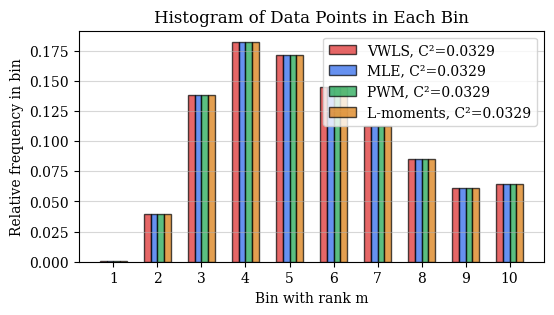

In [69]:
"""Histogram of the data points in each bin"""

fig,ax=plt.subplots()
#test
bin_list_mle=bin_list_vwls
bin_list_pwm=bin_list_vwls
bin_list_l_moments = bin_list_vwls


bin_list_plot=[
    bin_list_vwls,
    bin_list_mle,
    bin_list_pwm,
    bin_list_l_moments
    ]

label_list_plot=[
    f'VWLS, C²={c_2_vwls:.4f}',
    f'MLE, C²={c_2_vwls:.4f}',
    f'PWM, C²={c_2_vwls:.4f}',
    f'L-moments, C²={c_2_vwls:.4f}'
    ]
colors_plot=[
    my_colors['VWLS'],
    my_colors['MLE'],
    my_colors['PWM'],
    my_colors['L-moments']
    ]



ax.hist(bin_list_plot, bins=n_bins, density=True, color=colors_plot, alpha=0.7, rwidth=0.6, label=label_list_plot, edgecolor='black', align='right')
ax.set_xlabel('Bin with rank m')
ax.set_ylabel('Relative frequency in bin')
ax.set_title('Histogram of Data Points in Each Bin')
ax.set_xticks(range(1,n_bins+1))
ax.legend()
ax.grid(axis='y', alpha=0.5)
if save_figures:
    fig.savefig(f"{directory_figures}/bin_histogram.png")
